# Model Architecture Comparison — Conductor.fun Category Classifier

A head-to-head benchmark of 7 transfer-learning backbones on the augmented
conductor.fun dataset, to pick the best-performing architecture before
applying it to the harder per-item (312-class) locomotive identification task.

**Scope decision:** this notebook trains and compares models at the
**4-category level** (Automobiles / Freight Cars / Locomotives / Passenger
Train Cars) rather than per individual product. Training all 7 architectures
fully on a 312-class problem in one session would blow past Kaggle's session
time limits. This benchmark answers *which backbone transfers best to this
photo domain* — the winning architecture is then the one to apply to the
full per-item classifier separately.

**Models compared:**
1. MobileNetV2
2. MobileNetV3-Small
3. EfficientNet-B0
4. EfficientNet-Lite0 (via `timm`)
5. ResNet18
6. ResNet34
7. SqueezeNet1.1
8. CLIP (ViT-B/32) — frozen embeddings + linear probe (different paradigm, see Section 6)

**What this notebook produces:**
- Full EDA / readiness check on the augmented dataset
- Per-model training with identical data splits, epochs, and evaluation protocol
- 16 tracked metrics per model (accuracy, loss, precision/recall/F1, top-3 accuracy,
  ROC-AUC, model size, parameter count, training time, inference speed)
- Training curves, confusion matrices, and a radar/spider chart comparing all models
- A final weighted leaderboard and recommendation

**Dataset path:**
```
/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset
```

## 0. Setup & Installs

In [1]:
!pip install -q timm
# NOTE: deliberately NOT using --upgrade and NOT reinstalling torch/torchvision/scikit-learn —
# Kaggle's preinstalled versions are already matched to the assigned GPU. Upgrading them
# (or letting timm pull newer versions as a dependency) can silently break CUDA compatibility
# and cause 'no kernel image is available for execution on the device' errors.

In [2]:
import os
import time
import json
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models as tvmodels
import timm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, log_loss,
    top_k_accuracy_score, roc_auc_score, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset"

CATEGORIES = ["Automobiles", "Freight Cars", "Locomotives", "Passenger Train Cars"]
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12                # kept modest — this is a 7-way architecture bake-off, not a final model
LEARNING_RATE = 1e-3
NUM_CLASSES = len(CATEGORIES)

for cat in CATEGORIES:
    path = os.path.join(DATASET_ROOT, cat)
    print(f"{cat:24s} -> {'OK' if os.path.isdir(path) else 'MISSING'}")

Automobiles              -> OK
Freight Cars             -> OK
Locomotives              -> OK
Passenger Train Cars     -> OK


## 1. Data Analysis & Readiness Check

Condensed EDA — full detailed EDA already exists in a separate notebook for
this dataset; this section covers what's specifically relevant before training:
class balance, corrupt files, and resizing/format checks.

In [4]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

records = []
for category in CATEGORIES:
    cat_path = os.path.join(DATASET_ROOT, category)
    if not os.path.isdir(cat_path):
        continue
    for products_id in os.listdir(cat_path):
        item_path = os.path.join(cat_path, products_id)
        if not os.path.isdir(item_path):
            continue
        for fname in os.listdir(item_path):
            ext = os.path.splitext(fname)[1].lower()
            if ext in VALID_EXTS:
                records.append({'category': category, 'products_id': products_id,
                                 'filename': fname, 'path': os.path.join(item_path, fname)})

images_df = pd.DataFrame(records)
print(f"Total images found: {len(images_df)}")
print()
print('Images per category:')
print(images_df['category'].value_counts())

Total images found: 4135

Images per category:
category
Freight Cars            1660
Locomotives             1515
Passenger Train Cars     855
Automobiles              105
Name: count, dtype: int64


In [5]:
# Corrupt image check
corrupt = []
valid_rows = []
for _, row in images_df.iterrows():
    try:
        with Image.open(row['path']) as img:
            img.verify()
        with Image.open(row['path']) as img:
            w, h = img.size
        valid_rows.append({**row.to_dict(), 'width': w, 'height': h})
    except Exception as e:
        corrupt.append((row['path'], str(e)))

valid_df = pd.DataFrame(valid_rows)
print(f"Valid images: {len(valid_df)} / {len(images_df)}")
print(f"Corrupt images: {len(corrupt)}")
if corrupt:
    for p, e in corrupt:
        print(' ', p, '-', e)

Valid images: 4135 / 4135
Corrupt images: 0


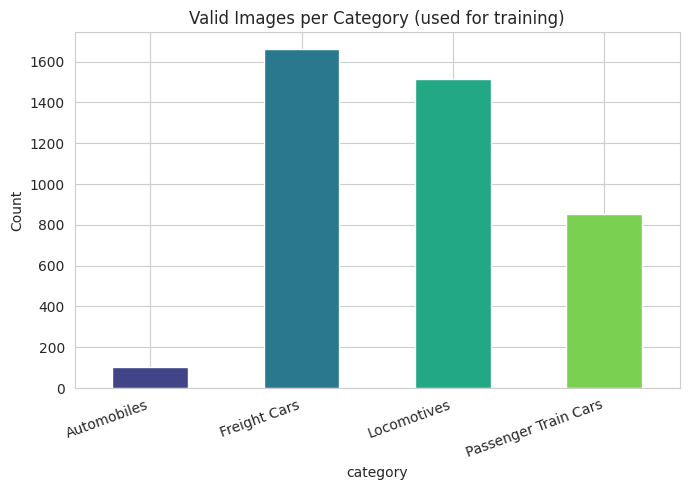

In [6]:
plt.figure(figsize=(7,5))
valid_df['category'].value_counts().reindex(CATEGORIES).plot(kind='bar', color=sns.color_palette('viridis', 4))
plt.title('Valid Images per Category (used for training)')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [7]:
print('Resolution summary:')
print(valid_df[['width','height']].describe())
print()
undersized = valid_df[(valid_df['width'] < IMG_SIZE) | (valid_df['height'] < IMG_SIZE)]
print(f"Images smaller than the {IMG_SIZE}x{IMG_SIZE} training size: {len(undersized)} "
      f"({len(undersized)/len(valid_df)*100:.1f}%) — these will be upscaled, which is fine but worth knowing.")

Resolution summary:
             width       height
count  4135.000000  4135.000000
mean    318.973398   231.228537
std     241.980593   157.062960
min     280.000000    98.000000
25%     280.000000   210.000000
50%     280.000000   210.000000
75%     280.000000   210.000000
max    2048.000000  1536.000000

Images smaller than the 224x224 training size: 4020 (97.2%) — these will be upscaled, which is fine but worth knowing.


## 2. Preprocessing, Splits & Augmentation

Images are resized to 224×224 (standard input size for all 7 architectures)
and normalized using ImageNet statistics, since every model here was
pretrained on ImageNet.

**On augmentation:** this dataset was already brought up to 5 images/item
via file-level augmentation (`augmentation_log.csv`). This section adds a
*second*, lighter layer of on-the-fly augmentation during training only —
standard practice on top of a fixed augmented set, and harmless since it's
randomized per-epoch rather than baked into fixed files.

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(6),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [9]:
class ConductorDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(df['category'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)
        label = self.class_to_idx[row['category']]
        return img, label

In [10]:
# Stratified-ish split by product folder (not just by image) so augmented
# variants of the same item don't leak across train/val/test splits.
products = valid_df[['category','products_id']].drop_duplicates().reset_index(drop=True)

train_products, val_products, test_products = [], [], []
for category in CATEGORIES:
    cat_products = products[products['category'] == category]['products_id'].tolist()
    random.shuffle(cat_products)
    n = len(cat_products)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)
    train_products += [(category, p) for p in cat_products[:n_train]]
    val_products += [(category, p) for p in cat_products[n_train:n_train+n_val]]
    test_products += [(category, p) for p in cat_products[n_train+n_val:]]

def filter_by_products(df, product_list):
    keys = set(product_list)
    return df[df.apply(lambda r: (r['category'], r['products_id']) in keys, axis=1)]

train_df = filter_by_products(valid_df, train_products)
val_df = filter_by_products(valid_df, val_products)
test_df = filter_by_products(valid_df, test_products)

print(f"Train images: {len(train_df)} ({len(train_products)} products)")
print(f"Val images:   {len(val_df)} ({len(val_products)} products)")
print(f"Test images:  {len(test_df)} ({len(test_products)} products)")

Train images: 2885 (577 products)
Val images:   610 (122 products)
Test images:  640 (128 products)


In [11]:
train_dataset = ConductorDataset(train_df, train_transform)
val_dataset = ConductorDataset(val_df, eval_transform)
test_dataset = ConductorDataset(test_df, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print('Classes:', CLASS_NAMES)

Classes: ['Automobiles', 'Freight Cars', 'Locomotives', 'Passenger Train Cars']


## 3. Model Zoo

One builder function per architecture, each returning a model with its final
layer replaced for our 4 classes. All models (except CLIP, handled separately
in Section 6) share the exact same training loop, so results are directly
comparable.

In [12]:
def build_mobilenet_v2(num_classes, pretrained=True):
    weights = tvmodels.MobileNet_V2_Weights.DEFAULT if pretrained else None
    model = tvmodels.mobilenet_v2(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def build_mobilenet_v3_small(num_classes, pretrained=True):
    weights = tvmodels.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
    model = tvmodels.mobilenet_v3_small(weights=weights)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

def build_efficientnet_b0(num_classes, pretrained=True):
    weights = tvmodels.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = tvmodels.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def build_efficientnet_lite0(num_classes, pretrained=True):
    model = timm.create_model('efficientnet_lite0', pretrained=pretrained, num_classes=num_classes)
    return model

def build_resnet18(num_classes, pretrained=True):
    weights = tvmodels.ResNet18_Weights.DEFAULT if pretrained else None
    model = tvmodels.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet34(num_classes, pretrained=True):
    weights = tvmodels.ResNet34_Weights.DEFAULT if pretrained else None
    model = tvmodels.resnet34(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_squeezenet(num_classes, pretrained=True):
    weights = tvmodels.SqueezeNet1_1_Weights.DEFAULT if pretrained else None
    model = tvmodels.squeezenet1_1(weights=weights)
    # SqueezeNet's classifier head is a Conv2d, not Linear — replace accordingly
    model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
    model.num_classes = num_classes
    return model

MODEL_BUILDERS = {
    'MobileNetV2': build_mobilenet_v2,
    'MobileNetV3-Small': build_mobilenet_v3_small,
    'EfficientNet-B0': build_efficientnet_b0,
    'EfficientNet-Lite0': build_efficientnet_lite0,
    'ResNet18': build_resnet18,
    'ResNet34': build_resnet34,
    'SqueezeNet1.1': build_squeezenet,
}

print(f"{len(MODEL_BUILDERS)} CNN architectures registered. CLIP handled separately (Section 6).")

7 CNN architectures registered. CLIP handled separately (Section 6).


## 4. Generic Training & Evaluation Loop

One shared function used for every CNN model, so training procedure,
epochs, optimizer, and evaluation protocol are identical across the board —
this is what makes the final comparison fair.

In [13]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    tmp_path = '_tmp_model_size_check.pt'
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

def measure_inference_speed(model, loader, n_batches=5):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches:
                break
            images = images.to(DEVICE)
            start = time.time()
            _ = model(images)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            elapsed = time.time() - start
            times.append(elapsed / images.size(0))
    return float(np.mean(times)) * 1000  # ms per image

In [14]:
def train_and_evaluate(model_name, builder_fn, num_classes=NUM_CLASSES, epochs=EPOCHS):
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    model = builder_fn(num_classes, pretrained=True).to(DEVICE)
    total_params, trainable_params = count_params(model)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history['train_acc'].append(train_acc)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"  Epoch {epoch+1}/{epochs} — train_acc: {train_acc:.3f} train_loss: {train_loss:.3f} "
              f"| val_acc: {val_acc:.3f} val_loss: {val_loss:.3f}")

    train_time_sec = time.time() - start_time

    # ---- Test set evaluation ----
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    test_loss_total = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev, labels_dev = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images_dev)
            loss = criterion(outputs, labels_dev)
            test_loss_total += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    test_loss = test_loss_total / len(all_labels)
    test_acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)

    all_probs_arr = np.array(all_probs)
    k = min(3, num_classes)
    top3_acc = top_k_accuracy_score(all_labels, all_probs_arr, k=k, labels=list(range(num_classes)))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs_arr, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = float('nan')

    size_mb = model_size_mb(model)
    inference_ms = measure_inference_speed(model, test_loader)

    cm = confusion_matrix(all_labels, all_preds)

    result = {
        'model_name': model_name,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'model_size_mb': size_mb,
        'train_time_sec': train_time_sec,
        'inference_ms_per_image': inference_ms,
        'train_acc': history['train_acc'][-1],
        'train_loss': history['train_loss'][-1],
        'val_acc': history['val_acc'][-1],
        'val_loss': history['val_loss'][-1],
        'test_acc': test_acc,
        'test_loss': test_loss,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
        'top3_acc': top3_acc,
        'roc_auc_macro': roc_auc,
    }

    return result, history, cm, model

## 5. Train All 7 CNN Architectures

Runs the identical training/eval procedure for each model. This is the
longest-running cell in the notebook — expect this to take a while
depending on Kaggle's assigned GPU.

In [15]:
all_results = []
all_histories = {}
all_confusion_matrices = {}

for model_name, builder_fn in MODEL_BUILDERS.items():
    result, history, cm, trained_model = train_and_evaluate(model_name, builder_fn)
    all_results.append(result)
    all_histories[model_name] = history
    all_confusion_matrices[model_name] = cm
    del trained_model  # not needed downstream — free memory immediately
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print('\n✅ All CNN models trained.')


Training: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 191MB/s]


  Epoch 1/12 — train_acc: 0.887 train_loss: 0.316 | val_acc: 0.911 val_loss: 0.312
  Epoch 2/12 — train_acc: 0.965 train_loss: 0.098 | val_acc: 0.911 val_loss: 0.231
  Epoch 3/12 — train_acc: 0.973 train_loss: 0.078 | val_acc: 0.936 val_loss: 0.300
  Epoch 4/12 — train_acc: 0.980 train_loss: 0.062 | val_acc: 0.949 val_loss: 0.133
  Epoch 5/12 — train_acc: 0.973 train_loss: 0.085 | val_acc: 0.918 val_loss: 0.308
  Epoch 6/12 — train_acc: 0.991 train_loss: 0.030 | val_acc: 0.964 val_loss: 0.115
  Epoch 7/12 — train_acc: 0.991 train_loss: 0.026 | val_acc: 0.956 val_loss: 0.106
  Epoch 8/12 — train_acc: 0.993 train_loss: 0.018 | val_acc: 0.939 val_loss: 0.191
  Epoch 9/12 — train_acc: 0.988 train_loss: 0.045 | val_acc: 0.885 val_loss: 0.446
  Epoch 10/12 — train_acc: 0.985 train_loss: 0.046 | val_acc: 0.948 val_loss: 0.223
  Epoch 11/12 — train_acc: 0.986 train_loss: 0.041 | val_acc: 0.941 val_loss: 0.151
  Epoch 12/12 — train_acc: 0.986 train_loss: 0.031 | val_acc: 0.956 val_loss: 0.133



100%|██████████| 9.83M/9.83M [00:00<00:00, 161MB/s]


  Epoch 1/12 — train_acc: 0.864 train_loss: 0.344 | val_acc: 0.677 val_loss: 1.192
  Epoch 2/12 — train_acc: 0.960 train_loss: 0.106 | val_acc: 0.939 val_loss: 0.214
  Epoch 3/12 — train_acc: 0.962 train_loss: 0.113 | val_acc: 0.923 val_loss: 0.209
  Epoch 4/12 — train_acc: 0.992 train_loss: 0.022 | val_acc: 0.892 val_loss: 0.675
  Epoch 5/12 — train_acc: 0.983 train_loss: 0.051 | val_acc: 0.834 val_loss: 0.802
  Epoch 6/12 — train_acc: 0.998 train_loss: 0.010 | val_acc: 0.943 val_loss: 0.185
  Epoch 7/12 — train_acc: 0.991 train_loss: 0.030 | val_acc: 0.898 val_loss: 0.372
  Epoch 8/12 — train_acc: 0.973 train_loss: 0.080 | val_acc: 0.916 val_loss: 0.243
  Epoch 9/12 — train_acc: 0.991 train_loss: 0.029 | val_acc: 0.938 val_loss: 0.172
  Epoch 10/12 — train_acc: 0.993 train_loss: 0.020 | val_acc: 0.944 val_loss: 0.112
  Epoch 11/12 — train_acc: 0.992 train_loss: 0.019 | val_acc: 0.851 val_loss: 0.824
  Epoch 12/12 — train_acc: 0.982 train_loss: 0.055 | val_acc: 0.916 val_loss: 0.292



...

  Epoch 1/12 — train_acc: 0.829 train_loss: 0.466 | val_acc: 0.848 val_loss: 0.402
  Epoch 2/12 — train_acc: 0.943 train_loss: 0.163 | val_acc: 0.854 val_loss: 0.439
  Epoch 3/12 — train_acc: 0.946 train_loss: 0.166 | val_acc: 0.793 val_loss: 1.014
  Epoch 4/12 — train_acc: 0.931 train_loss: 0.216 | val_acc: 0.808 val_loss: 0.686
  Epoch 5/12 — train_acc: 0.972 train_loss: 0.081 | val_acc: 0.892 val_loss: 0.330
  Epoch 6/12 — train_acc: 0.975 train_loss: 0.077 | val_acc: 0.839 val_loss: 0.500
  Epoch 7/12 — train_acc: 0.968 train_loss: 0.101 | val_acc: 0.923 val_loss: 0.356
  Epoch 8/12 — train_acc: 0.990 train_loss: 0.029 | val_acc: 0.915 val_loss: 0.348
  Epoch 9/12 — train_acc: 0.994 train_loss: 0.021 | val_acc: 0.879 val_loss: 0.358
  Epoch 10/12 — train_acc: 0.990 train_loss: 0.032 | val_acc: 0.826 val_loss: 0.658
  Epoch 11/12 — train_acc: 0.984 train_loss: 0.051 | val_acc: 0.923 val_loss: 0.245
  Epoch 12/12 — train_acc: 0.984 train_loss: 0.043 | val_acc: 0.726 val_loss: 1.113



100%|██████████| 83.3M/83.3M [00:00<00:00, 235MB/s]


  Epoch 1/12 — train_acc: 0.770 train_loss: 0.577 | val_acc: 0.685 val_loss: 0.857
  Epoch 2/12 — train_acc: 0.897 train_loss: 0.288 | val_acc: 0.772 val_loss: 0.616
  Epoch 3/12 — train_acc: 0.938 train_loss: 0.161 | val_acc: 0.848 val_loss: 0.450
  Epoch 4/12 — train_acc: 0.940 train_loss: 0.170 | val_acc: 0.864 val_loss: 0.528
  Epoch 5/12 — train_acc: 0.964 train_loss: 0.113 | val_acc: 0.875 val_loss: 0.464
  Epoch 6/12 — train_acc: 0.969 train_loss: 0.087 | val_acc: 0.875 val_loss: 0.593
  Epoch 7/12 — train_acc: 0.984 train_loss: 0.050 | val_acc: 0.877 val_loss: 0.421
  Epoch 8/12 — train_acc: 0.979 train_loss: 0.065 | val_acc: 0.867 val_loss: 0.461
  Epoch 9/12 — train_acc: 0.962 train_loss: 0.119 | val_acc: 0.907 val_loss: 0.311
  Epoch 10/12 — train_acc: 0.985 train_loss: 0.057 | val_acc: 0.900 val_loss: 0.284
  Epoch 11/12 — train_acc: 0.987 train_loss: 0.038 | val_acc: 0.936 val_loss: 0.249
  Epoch 12/12 — train_acc: 0.988 train_loss: 0.040 | val_acc: 0.905 val_loss: 0.431



100%|██████████| 4.73M/4.73M [00:00<00:00, 46.9MB/s]


  Epoch 1/12 — train_acc: 0.387 train_loss: 1.177 | val_acc: 0.402 val_loss: 1.099
  Epoch 2/12 — train_acc: 0.388 train_loss: 1.149 | val_acc: 0.402 val_loss: 1.220
  Epoch 3/12 — train_acc: 0.402 train_loss: 1.099 | val_acc: 0.451 val_loss: 1.036
  Epoch 4/12 — train_acc: 0.433 train_loss: 1.121 | val_acc: 0.369 val_loss: 1.145
  Epoch 5/12 — train_acc: 0.503 train_loss: 0.991 | val_acc: 0.526 val_loss: 0.986
  Epoch 6/12 — train_acc: 0.612 train_loss: 0.823 | val_acc: 0.564 val_loss: 1.118
  Epoch 7/12 — train_acc: 0.629 train_loss: 0.815 | val_acc: 0.644 val_loss: 0.788
  Epoch 8/12 — train_acc: 0.719 train_loss: 0.641 | val_acc: 0.662 val_loss: 0.744
  Epoch 9/12 — train_acc: 0.761 train_loss: 0.566 | val_acc: 0.692 val_loss: 0.655
  Epoch 10/12 — train_acc: 0.785 train_loss: 0.499 | val_acc: 0.744 val_loss: 0.641
  Epoch 11/12 — train_acc: 0.827 train_loss: 0.413 | val_acc: 0.790 val_loss: 0.497
  Epoch 12/12 — train_acc: 0.854 train_loss: 0.366 | val_acc: 0.789 val_loss: 0.513



## 6. CLIP (ViT-B/32) — Frozen Embeddings + Linear Probe

CLIP works fundamentally differently from the models above: instead of
training a classifier from scratch on top of pretrained features, we use
CLIP's image encoder **frozen** (no training at all) to convert every photo
into a fixed embedding vector, then train a simple, fast Logistic Regression
on those embeddings. This mirrors exactly how CLIP would be used in the
embedding/similarity-search architecture discussed for the full 312-item
problem, so this comparison is directly meaningful for that decision too.

In [26]:
def get_pooled_features(output):
    """Handles whatever shape get_image_features() returns across
    different transformers versions — a plain tensor, an object with
    .image_embeds, .pooler_output, or falls back to mean-pooling
    .last_hidden_state."""
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'last_hidden_state'):
        return output.last_hidden_state.mean(dim=1)
    raise TypeError(f"Unrecognized CLIP output type: {type(output)}")


def extract_clip_embeddings(df):
    embeddings, labels = [], []
    class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
    batch_size = 32
    paths = df['path'].tolist()
    cats = df['category'].tolist()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_cats = cats[i:i+batch_size]
        images = [Image.open(p).convert('RGB') for p in batch_paths]
        inputs = clip_processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            raw_output = clip_model.get_image_features(**inputs)
            feats = get_pooled_features(raw_output)
        embeddings.extend(feats.cpu().numpy())
        labels.extend([class_to_idx[c] for c in batch_cats])
    return np.array(embeddings), np.array(labels)

In [27]:
clip_start = time.time()

print('Extracting CLIP embeddings for train/val/test...')
X_train, y_train = extract_clip_embeddings(train_df)
X_val, y_val = extract_clip_embeddings(val_df)
X_test, y_test = extract_clip_embeddings(test_df)

embedding_time = time.time() - clip_start
print(f"Embedding extraction took {embedding_time:.1f}s for "
      f"{len(X_train)+len(X_val)+len(X_test)} images total.")

Extracting CLIP embeddings for train/val/test...
Embedding extraction took 20.9s for 4135 images total.


In [29]:
clip_head = LogisticRegression(max_iter=2000, multi_class='auto')

head_start = time.time()
clip_head.fit(X_train, y_train)
clip_train_time = time.time() - head_start + embedding_time

train_preds = clip_head.predict(X_train)
train_probs = clip_head.predict_proba(X_train)
val_preds = clip_head.predict(X_val)
val_probs = clip_head.predict_proba(X_val)
test_preds = clip_head.predict(X_test)
test_probs = clip_head.predict_proba(X_test)

clip_train_acc = accuracy_score(y_train, train_preds)
clip_train_loss = log_loss(y_train, train_probs, labels=list(range(NUM_CLASSES)))
clip_val_acc = accuracy_score(y_val, val_preds)
clip_val_loss = log_loss(y_val, val_probs, labels=list(range(NUM_CLASSES)))
clip_test_acc = accuracy_score(y_test, test_preds)
clip_test_loss = log_loss(y_test, test_probs, labels=list(range(NUM_CLASSES)))

clip_precision, clip_recall, clip_f1, _ = precision_recall_fscore_support(
    y_test, test_preds, average='macro', zero_division=0)
clip_top3 = top_k_accuracy_score(y_test, test_probs, k=min(3, NUM_CLASSES), labels=list(range(NUM_CLASSES)))
try:
    clip_roc_auc = roc_auc_score(y_test, test_probs, multi_class='ovr', average='macro')
except Exception:
    clip_roc_auc = float('nan')

clip_cm = confusion_matrix(y_test, test_preds)

# Inference speed: embedding extraction + LR predict, per image (measured on a small batch)
sample_imgs = [Image.open(p).convert('RGB') for p in test_df['path'].tolist()[:16]]
inf_start = time.time()
inputs = clip_processor(images=sample_imgs, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    raw_output = clip_model.get_image_features(**inputs)
    feats = get_pooled_features(raw_output)
_ = clip_head.predict(feats.cpu().numpy())
clip_inference_ms = (time.time() - inf_start) / len(sample_imgs) * 1000

clip_total_params = sum(p.numel() for p in clip_model.parameters())
clip_model_size = model_size_mb(clip_model)

clip_result = {
    'model_name': 'CLIP ViT-B/32 (linear probe)',
    'total_params': clip_total_params,
    'trainable_params': X_train.shape[1] * NUM_CLASSES,
    'model_size_mb': clip_model_size,
    'train_time_sec': clip_train_time,
    'inference_ms_per_image': clip_inference_ms,
    'train_acc': clip_train_acc,
    'train_loss': clip_train_loss,
    'val_acc': clip_val_acc,
    'val_loss': clip_val_loss,
    'test_acc': clip_test_acc,
    'test_loss': clip_test_loss,
    'precision_macro': clip_precision,
    'recall_macro': clip_recall,
    'f1_macro': clip_f1,
    'top3_acc': clip_top3,
    'roc_auc_macro': clip_roc_auc,
}

all_results.append(clip_result)
all_confusion_matrices['CLIP ViT-B/32 (linear probe)'] = clip_cm

print('✅ CLIP linear-probe evaluation complete.')
print(f"Test accuracy: {clip_test_acc:.3f}")

✅ CLIP linear-probe evaluation complete.
Test accuracy: 0.814


## 7. Results Table — All 16 Metrics, All 8 Models

In [30]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('test_acc', ascending=False).reset_index(drop=True)

display_cols = ['model_name', 'test_acc', 'val_acc', 'train_acc', 'test_loss', 'val_loss',
                 'train_loss', 'precision_macro', 'recall_macro', 'f1_macro', 'top3_acc',
                 'roc_auc_macro', 'model_size_mb', 'train_time_sec', 'inference_ms_per_image',
                 'total_params']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
results_df[display_cols].round(4)

,model_name,test_acc,val_acc,train_acc,test_loss,val_loss,train_loss,precision_macro,recall_macro,f1_macro,top3_acc,roc_auc_macro,model_size_mb,train_time_sec,inference_ms_per_image,total_params
0,EfficientNet-B0,0.9016,0.9607,0.9969,0.8016,0.1366,0.0087,0.9231,0.9306,0.9264,0.9969,0.9759,15.5966,200.4879,1.0571,4012672
1,MobileNetV2,0.8969,0.9557,0.9861,0.6626,0.1325,0.0306,0.9206,0.9214,0.9203,1.0000,0.9756,8.7406,162.1180,0.8421,2228996
2,EfficientNet-Lite0,0.8859,0.9344,0.9924,0.5696,0.1792,0.0266,0.9053,0.9091,0.9070,1.0000,0.9827,13.1416,176.5309,0.8992,3376132
3,ResNet34,0.8812,0.9049,0.9882,0.5828,0.4305,0.0399,0.9149,0.8999,0.9047,1.0000,0.9805,81.3394,204.9443,1.3252,21286724
4,MobileNetV3-Small,0.8766,0.9164,0.9820,0.7334,0.2925,0.0548,0.9116,0.8530,0.8781,1.0000,0.9712,5.9368,132.1704,0.3571,1521956
5,CLIP ViT-B/32 (linear probe),0.8141,0.8918,0.9938,0.5388,0.2847,0.0616,0.8644,0.8264,0.8437,1.0000,0.9517,577.2298,23.7910,11.9817,151277313
6,SqueezeNet1.1,0.7562,0.7885,0.8541,0.7645,0.5127,0.3659,0.7899,0.7962,0.7829,1.0000,0.9254,2.7839,131.5781,0.5131,724548
7,ResNet18,0.7531,0.7262,0.9844,1.3025,1.1135,0.0432,0.8309,0.8085,0.7827,0.9797,0.9639,42.7201,138.2942,0.7331,11178564


In [31]:
results_df.to_csv('model_comparison_results.csv', index=False)
print('Saved full results to model_comparison_results.csv')

Saved full results to model_comparison_results.csv


## 8. Training Curves — Per-Model Accuracy & Loss

CLIP is excluded here since it doesn't train over epochs the same way
(its 'training' is a one-shot linear regression fit on frozen embeddings).

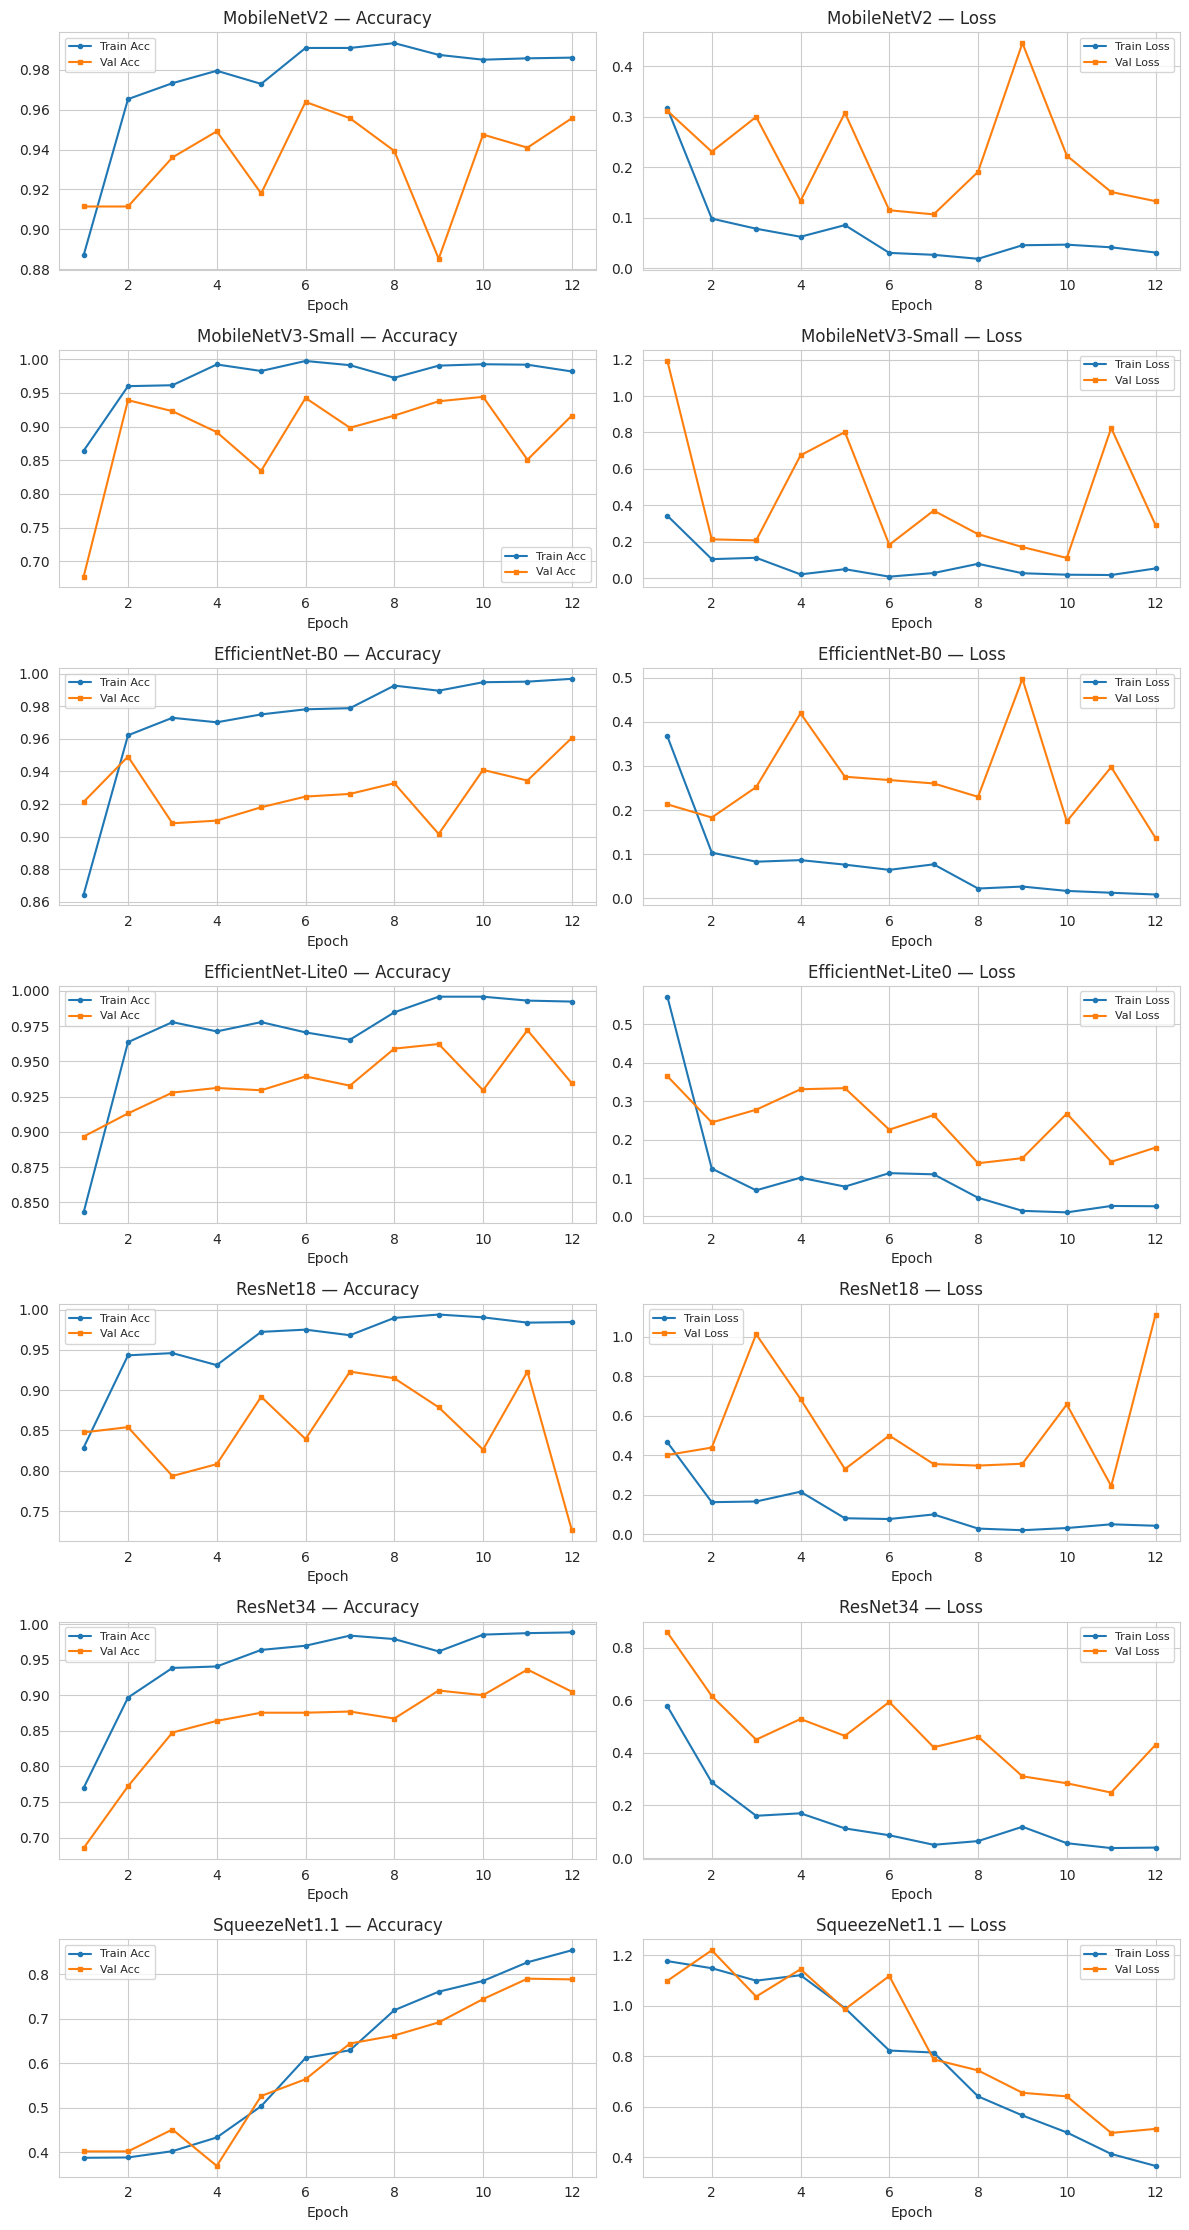

In [32]:
n_models = len(all_histories)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 3.2 * n_models))

for i, (model_name, history) in enumerate(all_histories.items()):
    epochs_range = range(1, len(history['train_acc']) + 1)

    axes[i, 0].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', markersize=3)
    axes[i, 0].plot(epochs_range, history['val_acc'], label='Val Acc', marker='s', markersize=3)
    axes[i, 0].set_title(f'{model_name} — Accuracy')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[i, 1].plot(epochs_range, history['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[i, 1].set_title(f'{model_name} — Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Confusion Matrices — All 8 Models

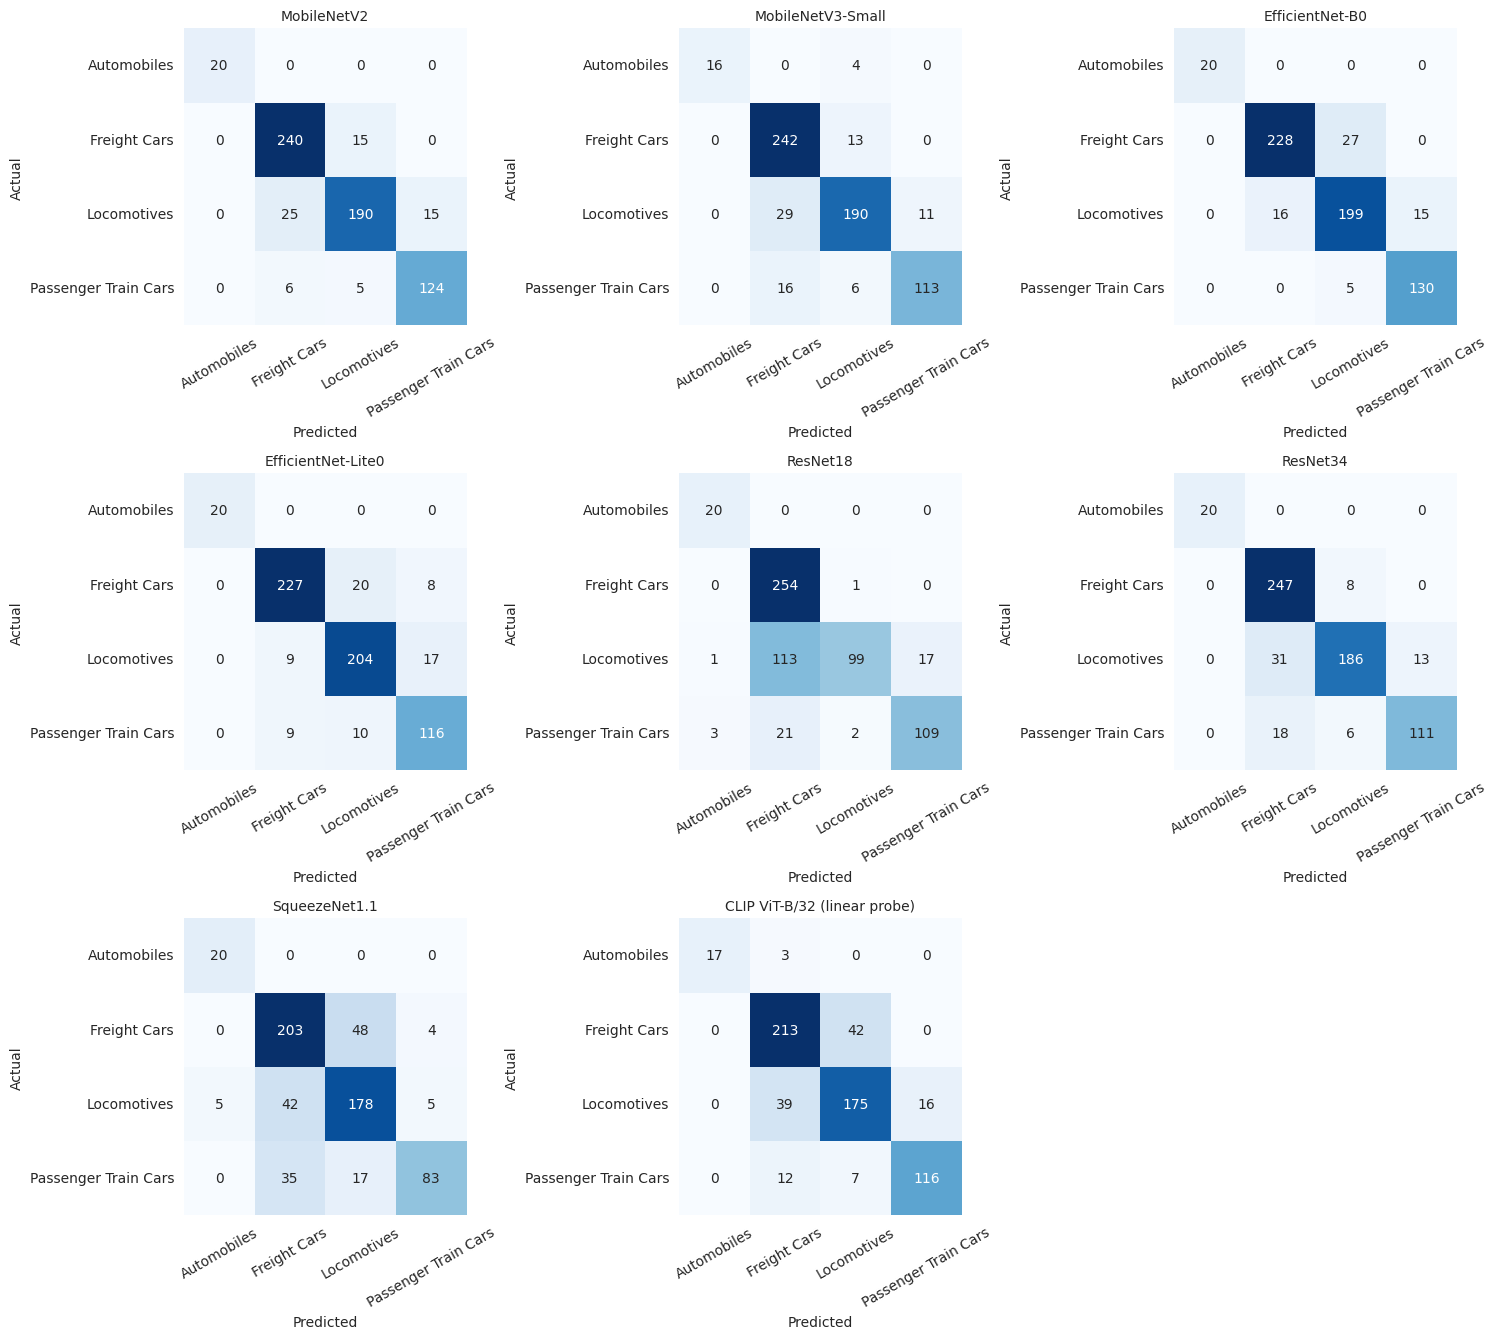

In [33]:
n_models_total = len(all_confusion_matrices)
cols = 3
rows = -(-n_models_total // cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(all_confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    axes[i].set_title(model_name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].tick_params(axis='y', rotation=0)

for j in range(n_models_total, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 10. Model Comparison — Radar / Spider Chart

Normalizes each metric to 0–1 across all models (inverting metrics where
*lower* is better — size, training time, inference time — so that on every
axis, further out = better). This means the model with the largest overall
shape is the best all-round performer, not just the most accurate one.

In [34]:
radar_metrics = {
    'Test Accuracy': ('test_acc', False),
    'F1 (macro)': ('f1_macro', False),
    'Top-3 Accuracy': ('top3_acc', False),
    'ROC-AUC': ('roc_auc_macro', False),
    'Small Size': ('model_size_mb', True),      # inverted: smaller is better
    'Fast Inference': ('inference_ms_per_image', True),  # inverted: faster is better
    'Fast Training': ('train_time_sec', True),  # inverted: faster is better
}

radar_df = results_df.set_index('model_name')
normalized = pd.DataFrame(index=radar_df.index)

for label, (col, invert) in radar_metrics.items():
    values = radar_df[col].fillna(radar_df[col].median())
    vmin, vmax = values.min(), values.max()
    if vmax == vmin:
        normalized[label] = 1.0
    else:
        norm = (values - vmin) / (vmax - vmin)
        normalized[label] = (1 - norm) if invert else norm

normalized.round(3)

,Test Accuracy,F1 (macro),Top-3 Accuracy,ROC-AUC,Small Size,Fast Inference,Fast Training
model_name,,,,,,,
EfficientNet-B0,1.000,1.000,0.846,0.881,0.978,0.940,0.025
MobileNetV2,0.968,0.957,1.000,0.876,0.990,0.958,0.236
EfficientNet-Lite0,0.895,0.865,1.000,1.000,0.982,0.953,0.157
ResNet34,0.863,0.849,1.000,0.961,0.863,0.917,0.000
MobileNetV3-Small,0.832,0.663,1.000,0.800,0.995,1.000,0.402
CLIP ViT-B/32 (linear probe),0.411,0.425,1.000,0.459,0.000,0.000,1.000
SqueezeNet1.1,0.021,0.002,1.000,0.000,1.000,0.987,0.405
ResNet18,0.000,0.000,0.000,0.673,0.930,0.968,0.368


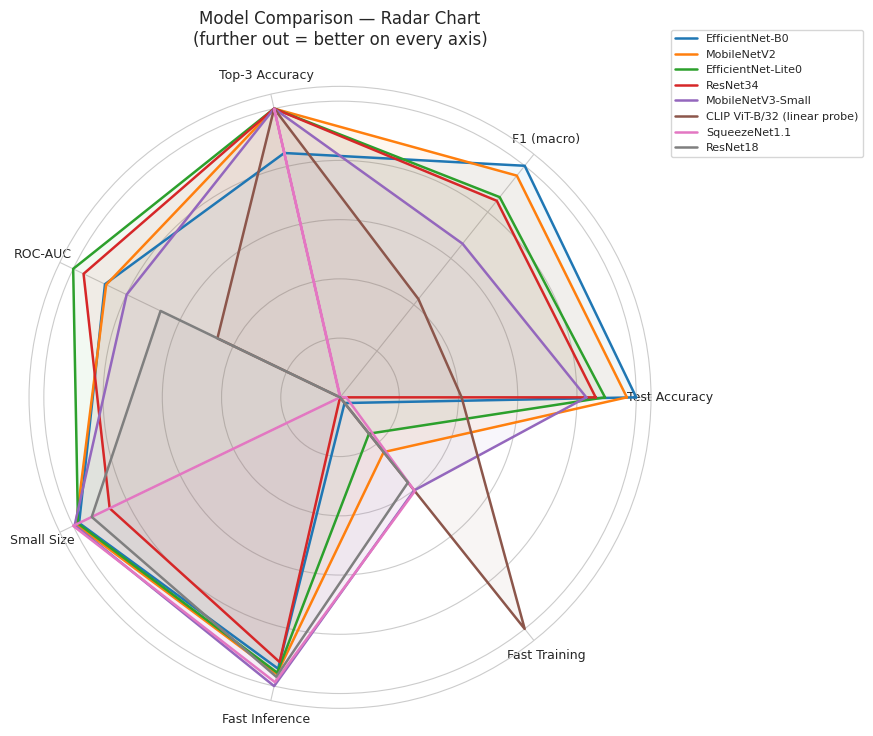

In [35]:
labels = list(radar_metrics.keys())
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = sns.color_palette('tab10', len(normalized))
for i, (model_name, row) in enumerate(normalized.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model_name, color=colors[i], linewidth=1.8)
    ax.fill(angles, values, color=colors[i], alpha=0.06)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title('Model Comparison — Radar Chart\n(further out = better on every axis)', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

## 11. Additional Comparison Views — Size, Speed, Accuracy Trade-offs

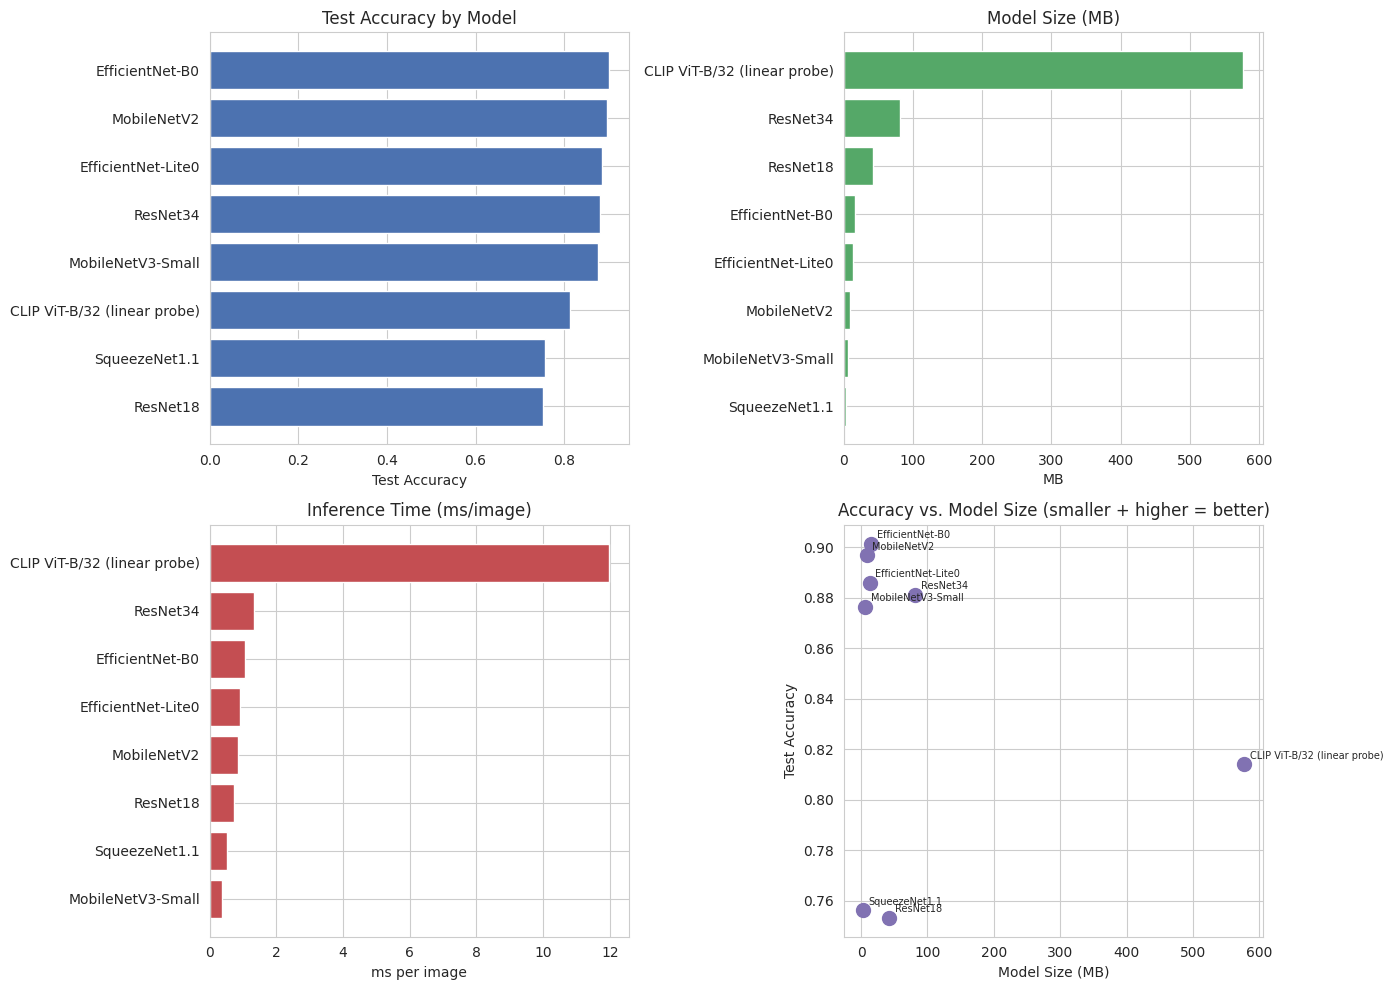

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sorted_by_acc = results_df.sort_values('test_acc')
axes[0,0].barh(sorted_by_acc['model_name'], sorted_by_acc['test_acc'], color='#4C72B0')
axes[0,0].set_title('Test Accuracy by Model')
axes[0,0].set_xlabel('Test Accuracy')

sorted_by_size = results_df.sort_values('model_size_mb')
axes[0,1].barh(sorted_by_size['model_name'], sorted_by_size['model_size_mb'], color='#55A868')
axes[0,1].set_title('Model Size (MB)')
axes[0,1].set_xlabel('MB')

sorted_by_speed = results_df.sort_values('inference_ms_per_image')
axes[1,0].barh(sorted_by_speed['model_name'], sorted_by_speed['inference_ms_per_image'], color='#C44E52')
axes[1,0].set_title('Inference Time (ms/image)')
axes[1,0].set_xlabel('ms per image')

axes[1,1].scatter(results_df['model_size_mb'], results_df['test_acc'], s=100, color='#8172B2')
for _, row in results_df.iterrows():
    axes[1,1].annotate(row['model_name'], (row['model_size_mb'], row['test_acc']),
                        fontsize=7, xytext=(4,4), textcoords='offset points')
axes[1,1].set_title('Accuracy vs. Model Size (smaller + higher = better)')
axes[1,1].set_xlabel('Model Size (MB)')
axes[1,1].set_ylabel('Test Accuracy')

plt.tight_layout()
plt.show()

## 12. Final Weighted Leaderboard & Recommendation

Combines accuracy and efficiency into a single weighted score:
**50% test accuracy, 20% F1-score, 15% model size (smaller better), 15%
inference speed (faster better)** — adjust these weights if your priorities
differ (e.g. weight size/speed higher if the VPS budget is tight).

In [37]:
def minmax_norm(series, invert=False):
    vmin, vmax = series.min(), series.max()
    if vmax == vmin:
        return pd.Series(1.0, index=series.index)
    norm = (series - vmin) / (vmax - vmin)
    return (1 - norm) if invert else norm

score_df = results_df.copy()
score_df['norm_acc'] = minmax_norm(score_df['test_acc'])
score_df['norm_f1'] = minmax_norm(score_df['f1_macro'])
score_df['norm_size'] = minmax_norm(score_df['model_size_mb'], invert=True)
score_df['norm_speed'] = minmax_norm(score_df['inference_ms_per_image'], invert=True)

score_df['weighted_score'] = (
    0.50 * score_df['norm_acc'] +
    0.20 * score_df['norm_f1'] +
    0.15 * score_df['norm_size'] +
    0.15 * score_df['norm_speed']
)

leaderboard = score_df.sort_values('weighted_score', ascending=False)
leaderboard[['model_name', 'test_acc', 'f1_macro', 'model_size_mb',
             'inference_ms_per_image', 'weighted_score']].round(4)

,model_name,test_acc,f1_macro,model_size_mb,inference_ms_per_image,weighted_score
0,EfficientNet-B0,0.9016,0.9264,15.5966,1.0571,0.9876
1,MobileNetV2,0.8969,0.9203,8.7406,0.8421,0.9679
2,EfficientNet-Lite0,0.8859,0.9070,13.1416,0.8992,0.9106
3,ResNet34,0.8812,0.9047,81.3394,1.3252,0.8683
4,MobileNetV3-Small,0.8766,0.8781,5.9368,0.3571,0.8477
6,SqueezeNet1.1,0.7562,0.7829,2.7839,0.5131,0.3088
5,CLIP ViT-B/32 (linear probe),0.8141,0.8437,577.2298,11.9817,0.2902
7,ResNet18,0.7531,0.7827,42.7201,0.7331,0.2847


In [38]:
winner = leaderboard.iloc[0]
print('='*60)
print('RECOMMENDATION')
print('='*60)
print(f"Best overall (weighted) model: {winner['model_name']}")
print(f"  Test accuracy:        {winner['test_acc']:.3f}")
print(f"  F1 (macro):           {winner['f1_macro']:.3f}")
print(f"  Model size:           {winner['model_size_mb']:.1f} MB")
print(f"  Inference speed:      {winner['inference_ms_per_image']:.2f} ms/image")
print(f"  Weighted score:       {winner['weighted_score']:.3f}")
print()
print('Runner-up:', leaderboard.iloc[1]['model_name'])
print()
print('NOTE: This benchmark was run at the 4-category level for time/compute')
print('reasons. Before committing to this architecture for the full 312-item')
print('locomotive classifier, re-validate on a small sample of real per-item')
print('classes — a model that wins at coarse category separation does not')
print('automatically win at fine-grained, near-identical item disambiguation.')

RECOMMENDATION
Best overall (weighted) model: EfficientNet-B0
  Test accuracy:        0.902
  F1 (macro):           0.926
  Model size:           15.6 MB
  Inference speed:      1.06 ms/image
  Weighted score:       0.988

Runner-up: MobileNetV2

NOTE: This benchmark was run at the 4-category level for time/compute
reasons. Before committing to this architecture for the full 312-item
locomotive classifier, re-validate on a small sample of real per-item
classes — a model that wins at coarse category separation does not
automatically win at fine-grained, near-identical item disambiguation.
